                                  name  selling_price  year seller_type  \
0            Royal Enfield Classic 350         175000  2019  Individual   
1                            Honda Dio          45000  2017  Individual   
2  Royal Enfield Classic Gunmetal Grey         150000  2018  Individual   
3    Yamaha Fazer FI V 2.0 [2016-2018]          65000  2015  Individual   
4                Yamaha SZ [2013-2014]          20000  2011  Individual   

       owner  km_driven  ex_showroom_price  
0  1st owner        350                NaN  
1  1st owner       5650                NaN  
2  1st owner      12000           148114.0  
3  1st owner      23000            89643.0  
4  2nd owner      21000                NaN  
price range:755000
median price: 45000.0
most common seller type: Individual
number of bikes driven more than 50000 km: 170
average_km_driven: owner
1st owner     32816.583333
2nd owner     39288.991870
3rd owner     33292.181818
4th owner    311500.000000
Name: km_driven, dtype

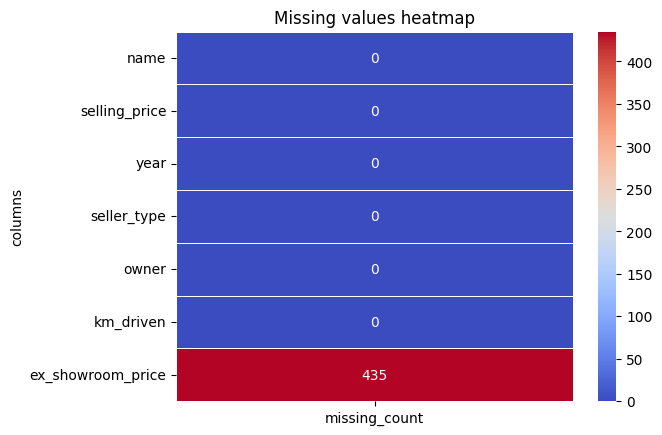

highest showroom price bike name: Harley-Davidson Street Bob


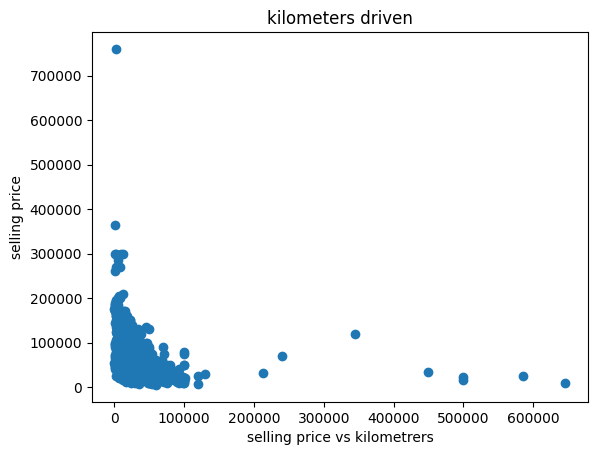

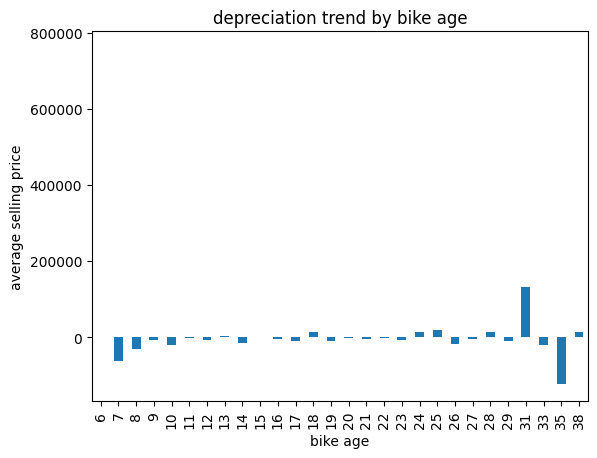

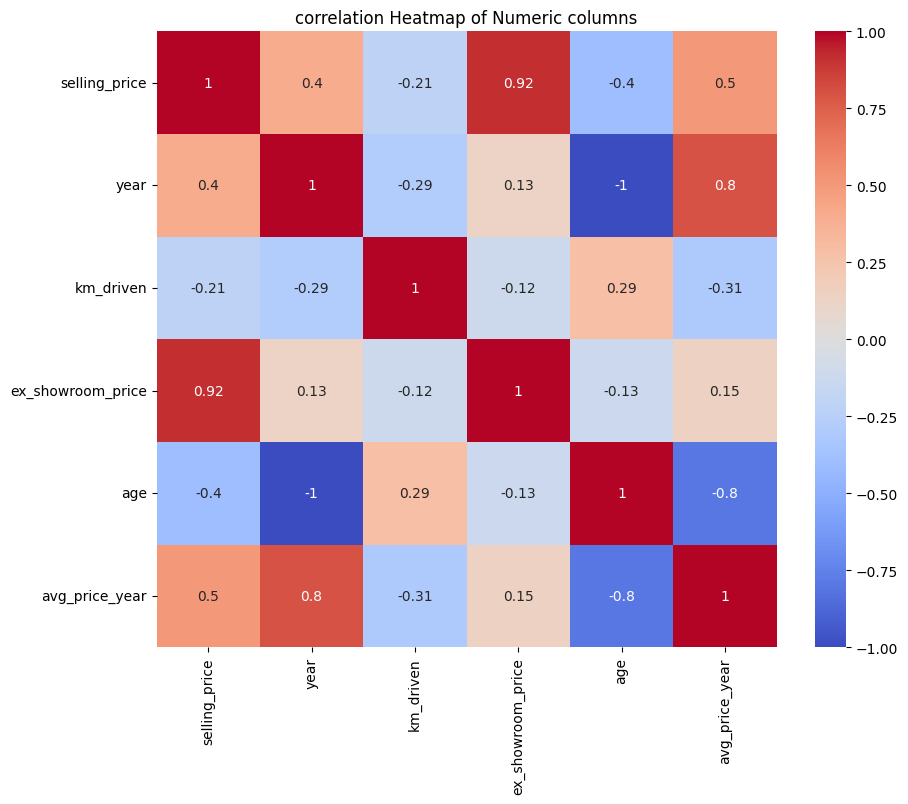

In [ ]:
######EDA BIKE DATA SET#########
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("BIKE DETAILS.csv")
print(df.head())

#Q:1
min_price = df["selling_price"].min()
max_price = df["selling_price"].max()
price_range = max_price-min_price
print(f"price range:{price_range}")

#Q:2 
median_price = df["selling_price"].median()
print("median price:", median_price)

#Q:3
df["seller_type"].value_counts(ascending=True)
most_common_seller_type = df["seller_type"].mode()[0]
print("most common seller type:", most_common_seller_type)

#Q:4
count = df[df["km_driven"] > 50000].shape[0]
print("number of bikes driven more than 50000 km:", count)

#Q:5
average_km_driven=df.groupby('owner')['km_driven'].mean()
print("average_km_driven:", average_km_driven)

#Q:6
total_bikes = df.shape[0]
older_bikes = df[df["year"] <=2015].shape[0]
portion_above_2015 = (older_bikes / total_bikes)*100
print("portion of bikes manufactured after 2015:", portion_above_2015)

#Q:7
missing_values = df.isnull().sum()
# convert to a DataFrame so heatmap receives a 2D array (avoids inconsistent-shape error)
missing_values_df = missing_values.to_frame(name='missing_count')
sns.heatmap(missing_values_df, annot=True, fmt='d', cmap="coolwarm", linewidths=0.5)
plt.title("Missing values heatmap")
plt.ylabel("columns")
plt.show()

#Q:8
mx_price = df['ex_showroom_price'].max()
bike_name = df[df["ex_showroom_price"] == mx_price]["name"].values[0]
print("highest showroom price bike name:",bike_name)

#Q:9
df["seller_type"].value_counts().sort_values(ascending=False)

#Q:10
first_owner = df[df["owner"] == "1st owner"]
first_owner[["selling_price","km_driven"]].corr()

plt.scatter(first_owner["km_driven"], first_owner["selling_price"])
plt.title("kilometers driven")
plt.xlabel("selling price vs kilometrers")
plt.ylabel("selling price")
plt.show()

#Q:11
def detect_outliers(columns):
    outlier_indices =[]
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR= Q3 - Q1
        mask=(df[column]>=(Q1 - 1.5 * IQR))&(df[column]<=(Q3 + 1.5 * IQR))
        mask=mask.to_numpy()

        false_indices = np.argwhere(~mask)
        outlier_indices.append(false_indices)
        return np.unique(np.concatenate(outlier_indices).ravel())

num_cols = ["km_driven"]
detect_outliers(num_cols)

#Q:12
sns.scatterplot(x = 'year', y = 'selling_price', data=df, palette ="viridis")
plt.title("Year vs Selling Price")

#Q:13
current_year = 2026
df["age"] = current_year - df["year"]
avg_price_by_age = df.groupby("age")["selling_price"].mean()
depreciation = avg_price_by_age.diff()
depreciation.plot(kind="bar")
plt.xlabel("bike age")
plt.ylabel("average selling price")
plt.title("depreciation trend by bike age")
plt.show()

#Q:14
avg_price_year = df.groupby("year")["selling_price"].mean()
df["avg_price_year"] = df["year"].map(avg_price_year)
expensive_bikes = df[df["selling_price"] > 1.5 * df["avg_price_year"]]
#shows bike names
expensive_bikes[["name" , "year", "selling_price", "avg_price_year"]]

#Q:15
num_cols = df.select_dtypes(exclude = "object").columns
corr_matrix = df[num_cols].corr()



plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("correlation Heatmap of Numeric columns")
plt.show()

















